# Imports

In [1]:
#Chenk enviroment
import sys
print(sys.executable)

c:\Users\laura.maestro\repos\ds_l7\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Initial exploration & data checks


## Load data

In [ ]:
# Path is relative to Notebooks/. Archived exploration; see README for the module equivalents.
df = pd.read_csv(
    "../corona_tested_individuals_ver_006.english.csv",
    dtype={"age_60_and_above": str},
)
df.shape


(278848, 10)

In [4]:
"../data/corona_tested_individuals_ver_006.english.csv"
(278848, 10)
"../data/corona_tested_individuals_ver_0083.english.csv"
(2742596, 10)

(2742596, 10)

In [5]:
df.sample(20)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
241426,2020-03-26,1.0,1.0,0.0,0.0,0.0,negative,No,male,Abroad
241494,2020-03-26,1.0,0.0,0.0,0.0,0.0,negative,Yes,female,Abroad
105104,2020-04-17,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
167136,2020-04-07,1.0,1.0,0.0,0.0,0.0,negative,Yes,female,Other
105982,2020-04-17,0.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
225701,2020-03-29,0.0,0.0,0.0,0.0,0.0,negative,No,female,Other
11146,2020-04-29,0.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
104801,2020-04-17,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
206430,2020-04-01,0.0,0.0,0.0,0.0,0.0,negative,Yes,male,Other
41340,2020-04-24,0.0,0.0,0.0,0.0,0.0,negative,NaN,male,Abroad


## Data Checks

### Shape and information 

In [6]:
df.info()  

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 29.2 MB


In [7]:
df.shape

(278848, 10)

In [8]:
df.describe(include="all")

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
count,278848,278596.000000,278596.000000,278847.000000,278847.000000,278847.000000,278848,151528,259285,278848
unique,51,NaN,NaN,NaN,NaN,NaN,3,2,2,3
top,2020-04-20,NaN,NaN,NaN,NaN,NaN,negative,No,female,Other
freq,10921,NaN,NaN,NaN,NaN,NaN,260227,125703,130158,242741
mean,NaN,0.151574,0.078077,0.006907,0.005655,0.008657,NaN,NaN,NaN,NaN
std,NaN,0.358608,0.268294,0.082821,0.074990,0.092640,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN


cough, fever, sore_throat, shortness_of_breath, head_ache are all booleans despite being stored as 1/0

We should consider transforming to booleans but what do we do with missing values?

In [9]:
symptom_cols = ["cough", "fever", "sore_throat", "shortness_of_breath", "head_ache"]
df[symptom_cols] = df[symptom_cols].astype("boolean")

In [10]:
df.sample(5)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
127374,2020-04-14,False,False,False,False,False,negative,Yes,female,Other
247432,2020-03-26,False,False,False,False,False,negative,No,male,Other
128200,2020-04-14,False,False,False,False,False,negative,No,male,Other
216985,2020-03-31,True,True,False,False,False,negative,No,female,Other
229740,2020-03-28,False,False,False,False,False,negative,No,male,Other


## Values and missing values

In [11]:
# Cardinality of categorical columns (spot ID-like columns, rare categories)
df.select_dtypes(include=["object", "string"]).nunique().sort_values(ascending=False)

test_date           51
corona_result        3
test_indication      3
age_60_and_above     2
gender               2
dtype: int64

In [12]:
cols=['cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication']
cols
for c in cols:
    #print(c)
    print(df[c].value_counts(normalize=True))
    print(df[c].value_counts(normalize=False))
    print("-"*56)
    print("Number of nulls:",df[c].isna().sum())
    print("="*56)

cough
False    0.848426
True     0.151574
Name: proportion, dtype: Float64
cough
False    236368
True      42228
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 252
fever
False    0.921923
True     0.078077
Name: proportion, dtype: Float64
fever
False    256844
True      21752
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 252
sore_throat
False    0.993093
True     0.006907
Name: proportion, dtype: Float64
sore_throat
False    276921
True       1926
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 1
shortness_of_breath
False    0.994345
True     0.005655
Name: proportion, dtype: Float64
shortness_of_breath
False    277270
True       1577
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 1
head_ache
False    0.991343
True     0.008657
Name: proportion, dtype: Float64
head_ache
False  

In [13]:
# Missingness overview
#df.isna().sum().sort_values(ascending=False)
print("Percentaje of missing values")
df.isna().mean().sort_values(ascending=False)   # as a proportion

Percentaje of missing values


age_60_and_above       0.456593
gender                 0.070157
fever                  0.000904
cough                  0.000904
head_ache              0.000004
sore_throat            0.000004
shortness_of_breath    0.000004
test_date              0.000000
corona_result          0.000000
test_indication        0.000000
dtype: float64

#### Categorical columns
Suggestion to fill in with unknown and create a 3rd category.
We could also take the most common value

Decision to replace with unknown


In [14]:
cat_cols=['age_60_and_above', 'gender','test_indication']
#df.columns
df[cat_cols] = df[cat_cols].fillna("unknown")   # categorical 

### Numerical columns - Symptoms


One of the things that the paper said is that absence of a symptom didn't mean the sympton was not present, it was a unknown.
Should we impute values for it with a value of 0.5?


Decision to drop the values.


In [15]:
# Missingness overview
#df.isna().sum().sort_values(ascending=False)
print("Percentaje of missing values")
df.isna().mean().sort_values(ascending=False)   # as a proportion

Percentaje of missing values


cough                  0.000904
fever                  0.000904
shortness_of_breath    0.000004
sore_throat            0.000004
head_ache              0.000004
test_date              0.000000
corona_result          0.000000
age_60_and_above       0.000000
gender                 0.000000
test_indication        0.000000
dtype: float64

In [16]:
# Drop rows
print("Before:",df.shape[0])
df.dropna(subset=['cough', 'fever', 'sore_throat', 'shortness_of_breath','head_ache'], axis=0, inplace=True, how='any')
print("After:",df.shape[0])

Before: 278848
After: 278594


In [17]:
# Missingness overview
#df.isna().sum().sort_values(ascending=False)
print("Percentaje of missing values")
df.isna().mean().sort_values(ascending=False)   # as a proportion


Percentaje of missing values


test_date              0.0
cough                  0.0
fever                  0.0
sore_throat            0.0
shortness_of_breath    0.0
head_ache              0.0
corona_result          0.0
age_60_and_above       0.0
gender                 0.0
test_indication        0.0
dtype: float64

### Result column

corona_result has 3 outcomes, unsure of what to do with the 660 (10%) values.


Decision to drop "Other"


In [18]:
print("Before:",df.shape[0])
df = df[df["corona_result"].str.lower() != "other"]
print("After:",df.shape[0])

df

Before: 278594
After: 274702


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,False,False,False,False,False,negative,unknown,female,Other
1,2020-04-30,True,False,False,False,False,negative,unknown,female,Other
2,2020-04-30,False,True,False,False,False,negative,unknown,male,Other
3,2020-04-30,True,False,False,False,False,negative,unknown,female,Other
4,2020-04-30,True,False,False,False,False,negative,unknown,male,Other
...,...,...,...,...,...,...,...,...,...,...
278842,2020-03-11,False,False,False,False,False,negative,unknown,unknown,Other
278843,2020-03-11,False,False,False,False,False,negative,unknown,unknown,Other
278844,2020-03-11,False,False,False,False,False,negative,unknown,unknown,Other
278845,2020-03-11,False,False,False,False,False,positive,unknown,unknown,Contact with confirmed


### Check for Outliers
In this dataset we don't have continuos variables that are outside 1

# Plot data

<Axes: >

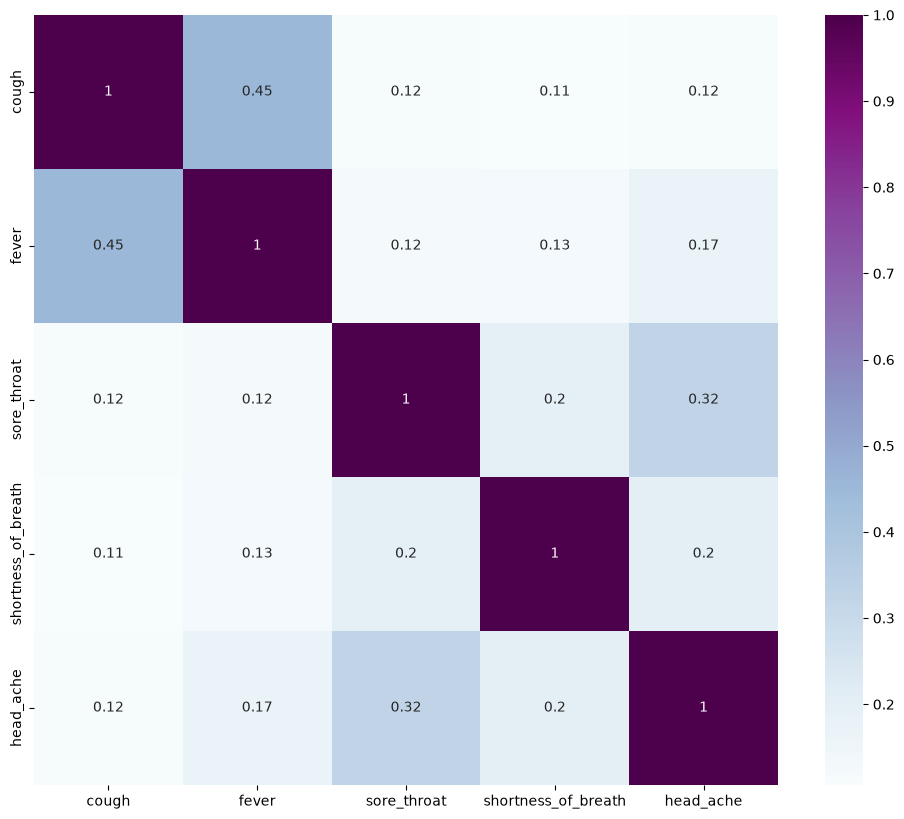

In [19]:
# Do we wnat to do anything different
import seaborn as sns
dfnum=df[symptom_cols] 
dfnum.corr()
# Correlation heatmap for numeric features
plt.figure(figsize=(12,10))
sns.heatmap(dfnum.corr(), annot=True, cmap='BuPu')

In [20]:
# dfplot = df.drop(columns=["test_date"])
# sns.pairplot(data=dfplot,hue="corona_result")
# plt.title('A')
# plt.show()



# Make Target column boolean

In [21]:
df['corona_result']=df["corona_result"]== "positive"
df.sample(5)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
221311,2020-03-30,False,False,False,False,False,False,No,male,Other
12431,2020-04-28,False,False,False,False,False,False,unknown,female,Other
67319,2020-04-21,False,False,False,False,False,False,unknown,male,Other
209058,2020-04-01,False,False,False,False,False,False,Yes,female,Other
165068,2020-04-07,False,False,False,False,False,False,No,female,Other


# Encoding categorical variables

In [22]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=bool)

df_cat = encoder.fit_transform(df[cat_cols])

#turn back into DataFrames with proper column names
encoded_cols = encoder.get_feature_names_out(cat_cols)
df_cat = pd.DataFrame(df_cat, columns=encoded_cols, index=df.index)

# drop original cat_cols and join the encoded ones back
df = pd.concat([df.drop(columns=cat_cols), df_cat], axis=1)

df=df.drop(columns=[ "test_date"])
df

,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above_No,age_60_and_above_Yes,age_60_and_above_unknown,gender_female,gender_male,gender_unknown,test_indication_Abroad,test_indication_Contact with confirmed,test_indication_Other
0,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True
1,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True
2,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True
3,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True
4,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278842,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
278843,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
278844,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
278845,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False


In [23]:
# from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=bool)

# X_cat = encoder.fit_transform(X[cat_cols])

# #turn back into DataFrames with proper column names
# encoded_cols = encoder.get_feature_names_out(cat_cols)
# X_cat = pd.DataFrame(X_cat, columns=encoded_cols, index=X.index)

# # drop original cat_cols and join the encoded ones back
# X = pd.concat([X.drop(columns=cat_cols), X_cat], axis=1)


<Axes: >

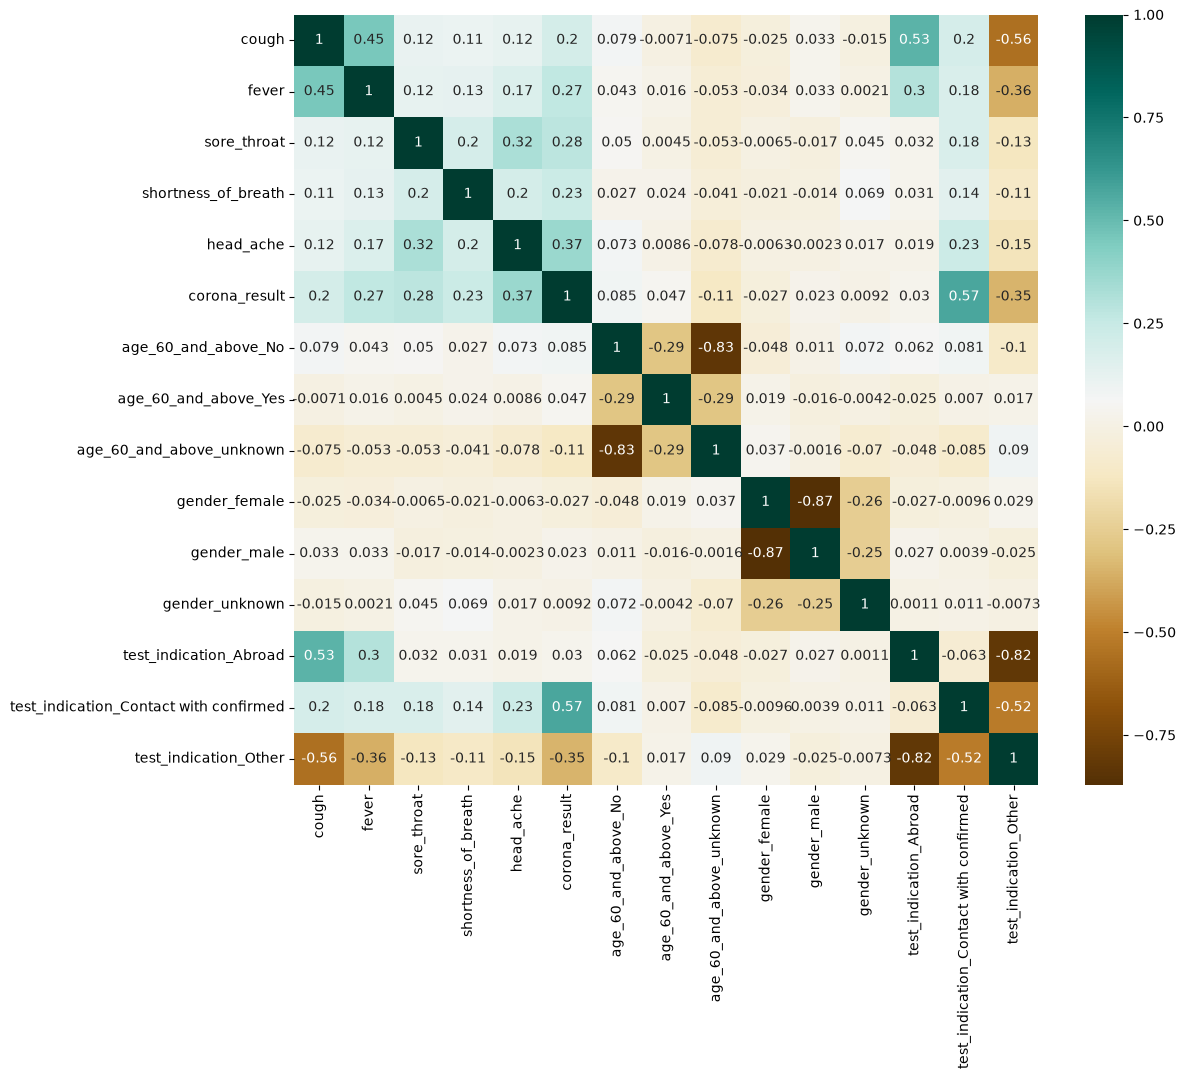

In [24]:
# Correlation heatmap for numeric features
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='BrBG')

# Train/test split & cross-validation setup

In [25]:
from sklearn.model_selection import train_test_split

target_col = "corona_result"
X = df.drop(columns=[target_col])
y = df[target_col]


#Train/test = 70/30


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Train/test = 70/30% =",len(X_train), len(X_test))
#Train/validation/test = 70/15/15


# Step 1: carve off the test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y,
)

# Step 2: split the remaining 85% into 70% train / 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=y_train_val,
)

print("Train/Val/Test = 70/15/15% =",len(X_train), len(X_val), len(X_test))

Train/test = 70/30% = 192291 82411
Train/Val/Test = 70/15/15% = 192290 41206 41206


In [26]:
X_train.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,age_60_and_above_No,age_60_and_above_Yes,age_60_and_above_unknown,gender_female,gender_male,gender_unknown,test_indication_Abroad,test_indication_Contact with confirmed,test_indication_Other
55865,False,False,False,False,False,False,False,True,False,False,True,False,False,True
46932,False,False,False,False,False,False,False,True,True,False,False,False,False,True
161508,True,True,False,False,False,True,False,False,True,False,False,True,False,False
150845,False,False,False,False,False,True,False,False,True,False,False,False,True,False
55417,False,False,False,False,False,False,False,True,False,True,False,False,False,True


## Model

### Naive Bayes

In [27]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print(f'Naive Bayes single model accuracy: {nb_model.score(X_test, y_test)}')

Naive Bayes single model accuracy: 0.9510508178420618


In [28]:
from sklearn.metrics import classification_report

nb_y_pred = nb_model.predict(X_test)


print('Naive Bayes')
print(classification_report(y_test, nb_y_pred))
print('='*53)


Naive Bayes
              precision    recall  f1-score   support

       False       0.98      0.97      0.97     39002
        True       0.53      0.66      0.59      2204

    accuracy                           0.95     41206
   macro avg       0.76      0.81      0.78     41206
weighted avg       0.96      0.95      0.95     41206



### Decision Tree Classifier

In [29]:
from sklearn.tree import DecisionTreeClassifier
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)
print(f'Decision Tree single model accuracy: {dtc_model.score(X_test, y_test)}')

Decision Tree single model accuracy: 0.9698587584332379


DecisionTreeClassifier
              precision    recall  f1-score   support

       False       0.98      0.99      0.98     39002
        True       0.80      0.58      0.67      2204

    accuracy                           0.97     41206
   macro avg       0.89      0.78      0.83     41206
weighted avg       0.97      0.97      0.97     41206

                                        importance
test_indication_Contact with confirmed    0.634104
head_ache                                 0.146853
sore_throat                               0.045150
shortness_of_breath                       0.036988
age_60_and_above_unknown                  0.030065
fever                                     0.029218
cough                                     0.025375
age_60_and_above_Yes                      0.011798
gender_unknown                            0.011599
age_60_and_above_No                       0.010426
test_indication_Other                     0.006651
gender_female                         

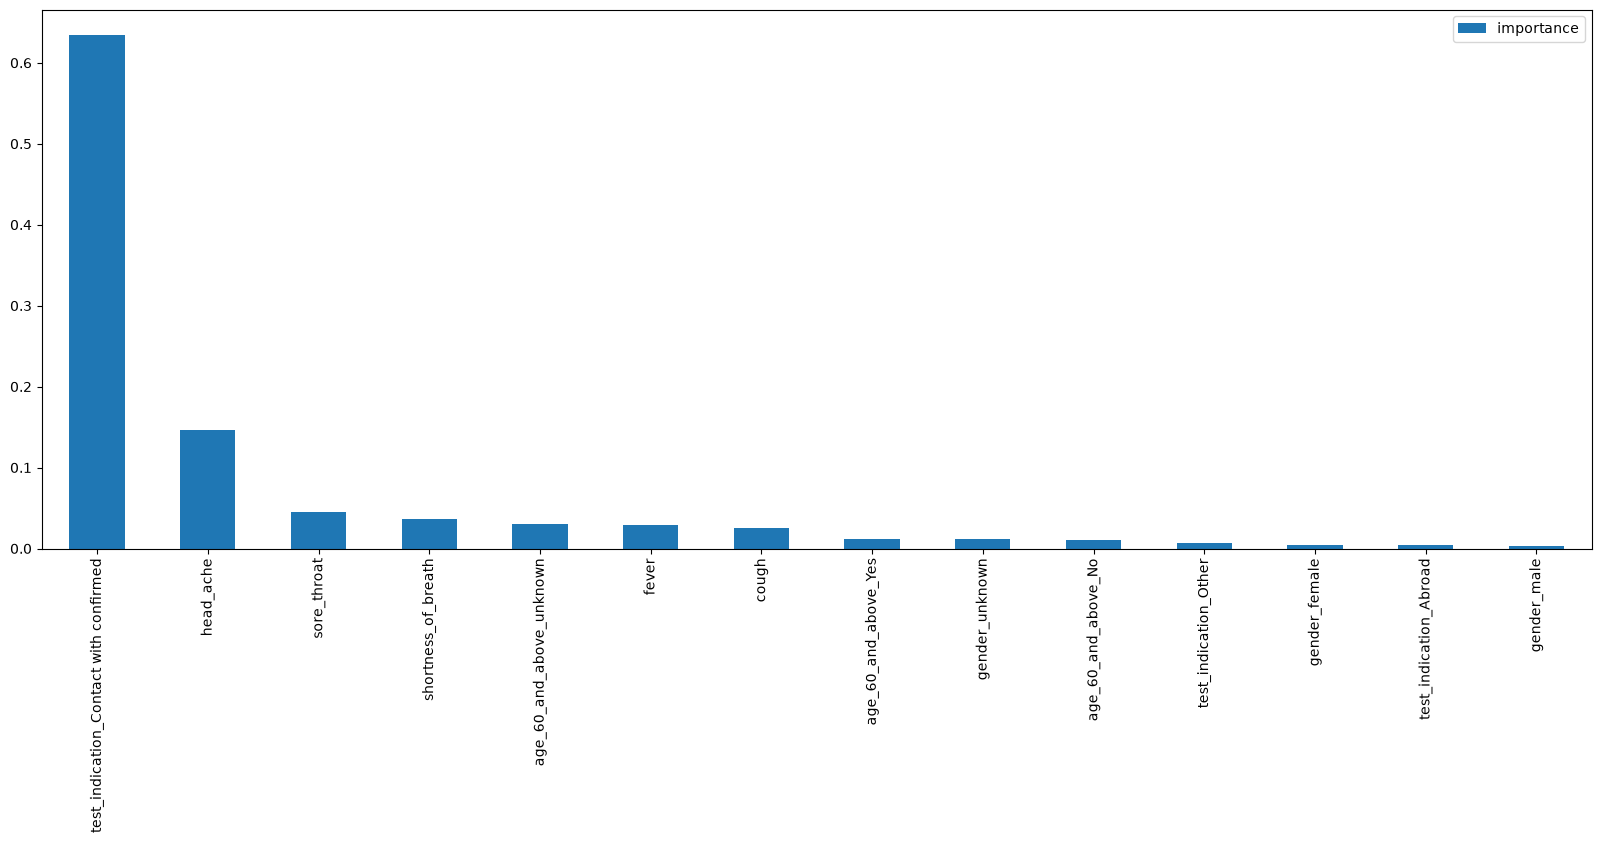

In [30]:
dtc_y_pred = dtc_model.predict(X_test)

print('DecisionTreeClassifier')
print(classification_report(y_test, dtc_y_pred))

print('='*53)

importances_df = pd.DataFrame(
    dtc_model.feature_importances_,
    columns=["importance"],
    index=X_train.columns
)
print(importances_df.sort_values("importance", ascending=False))

importances_df.sort_values("importance", ascending=False).plot(kind="bar", figsize=(20,7))
plt.show()


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    max_samples=0.9,   
    random_state=42)

rf.fit(X_train, y_train)

rf_y_pred = rf.predict(X_test)




              precision    recall  f1-score   support

       False       0.98      0.99      0.98     39002
        True       0.80      0.58      0.67      2204

    accuracy                           0.97     41206
   macro avg       0.89      0.79      0.83     41206
weighted avg       0.97      0.97      0.97     41206

                                        importance
test_indication_Contact with confirmed    0.362738
head_ache                                 0.135650
test_indication_Other                     0.102937
test_indication_Abroad                    0.095471
sore_throat                               0.072360
fever                                     0.068118
shortness_of_breath                       0.053164
cough                                     0.040245
age_60_and_above_unknown                  0.022040
gender_unknown                            0.013411
age_60_and_above_No                       0.011517
age_60_and_above_Yes                      0.010241
gender_mal

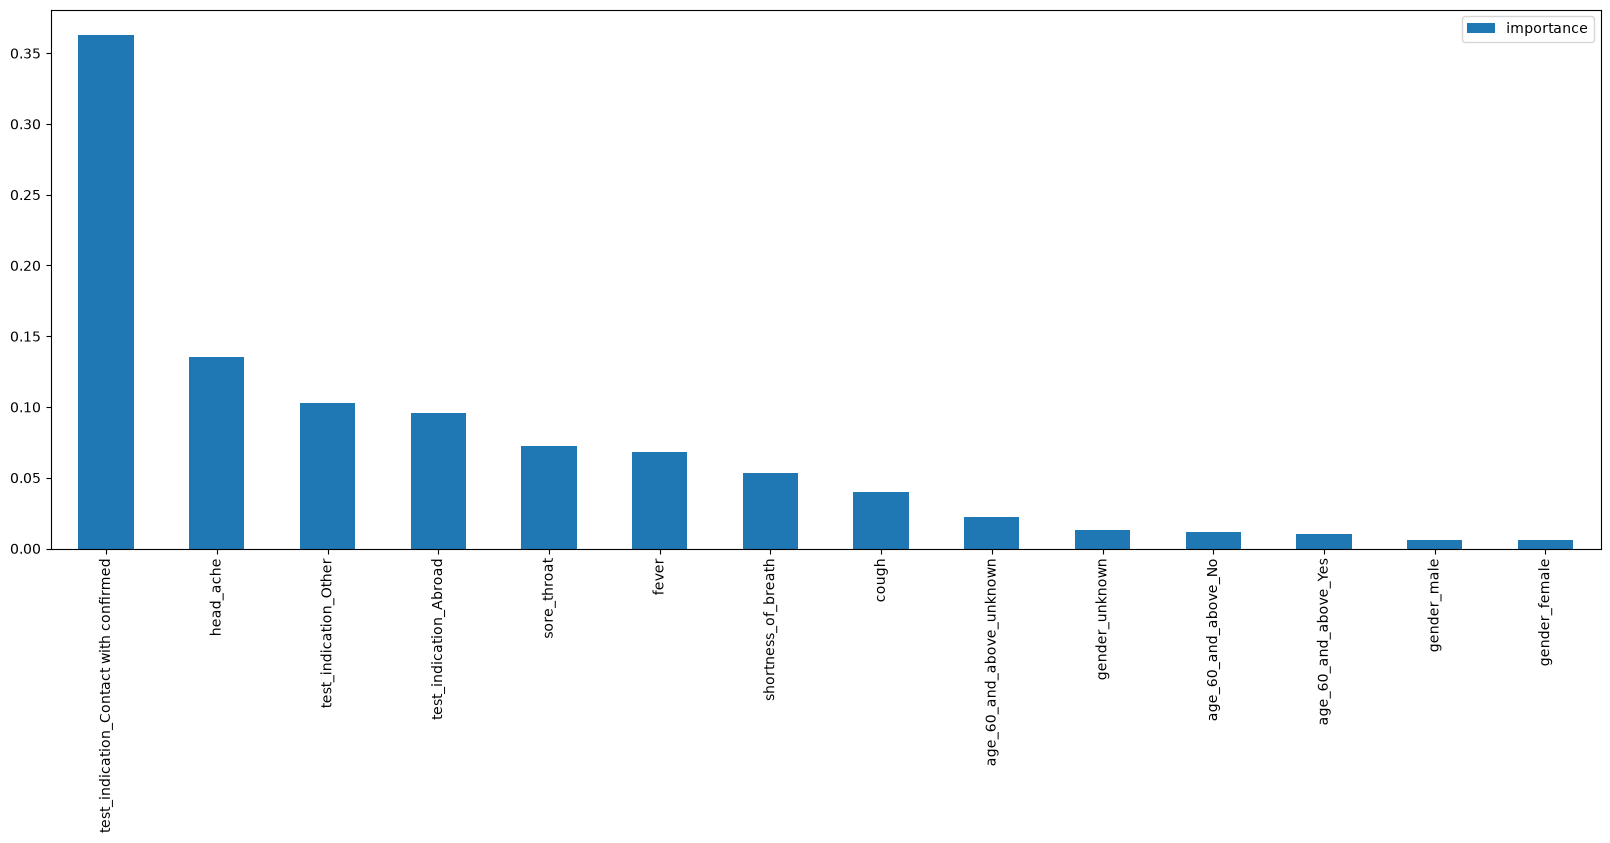

In [32]:
print(classification_report(y_test, rf_y_pred))
print('='*53)


importances_df = pd.DataFrame(
    rf.feature_importances_,
    columns=["importance"],
    index=X_train.columns
)
print(importances_df.sort_values("importance", ascending=False))

importances_df.sort_values("importance", ascending=False).plot(kind="bar", figsize=(20,7))
plt.show()

### Gradient Boost Classifier

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc_model.fit(X_train, y_train)

# # Make predictions and evaluate
gbc_y_pred = gbc_model.predict(X_test)

print(f'Gradient boost classifier accuracy: {gbc_model.score(X_test, y_test)}')


Gradient boost classifier accuracy: 0.9697859535019172


In [34]:
print(classification_report(y_test, gbc_y_pred))
print('='*53)


              precision    recall  f1-score   support

       False       0.98      0.99      0.98     39002
        True       0.80      0.58      0.67      2204

    accuracy                           0.97     41206
   macro avg       0.89      0.78      0.83     41206
weighted avg       0.97      0.97      0.97     41206



### Grid Search for random Forest

In [39]:
from sklearn.model_selection import GridSearchCV

params = dict(
    n_estimators=[100, 200],
    max_depth=[None], #, 1, 2],
    min_samples_split=[2, 3, 4],
    min_samples_leaf=[1, 2],
    max_samples=[0.75, 0.25, 0.9],
    random_state=[42]
    
)

rf2 = RandomForestClassifier(random_state=5, n_jobs=-1)

gcv = GridSearchCV(estimator=rf2, param_grid=params, n_jobs=-1, verbose=2)

gcv.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=5)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_samples': [0.75, 0.25, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 3, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or mu

## Confusion Matrixes and ROC curves

In [40]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
def DrawROC(model, Xtest, ytest, label=None, reset=False):
    # Create the figure/axes once and stash them on the function itself,
    # so repeated calls plot onto the same figure instead of opening a new one.
    if reset or not hasattr(DrawROC, "fig"):
        DrawROC.fig, DrawROC.ax = plt.subplots()
        DrawROC.ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
        DrawROC.ax.set_xlabel("False Positive Rate")
        DrawROC.ax.set_ylabel("True Positive Rate")
        DrawROC.ax.set_title("ROC Curve")

    yproba = model.predict_proba(Xtest)
    fpr, tpr, thresholds = roc_curve(ytest, yproba[:, 1])
    auc = roc_auc_score(ytest, yproba[:, 1])

    name = label or type(model).__name__
    print(f"{name} ROC AUC Score: {auc}")

    DrawROC.ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    DrawROC.ax.legend()

    return DrawROC.fig



GaussianNB ROC AUC Score: 0.8986867361076276
DecisionTreeClassifier ROC AUC Score: 0.907473734885018
GradientBoostingClassifier ROC AUC Score: 0.9093927055348551
RandomForestClassifier ROC AUC Score: 0.9093142857116268


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

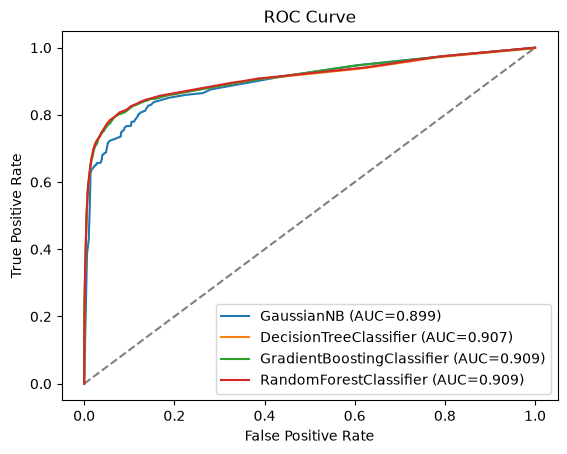

In [41]:
DrawROC(nb_model, X_test, y_test)
DrawROC(dtc_model, X_test, y_test)
DrawROC(gbc_model, X_test, y_test)
DrawROC(rf, X_test, y_test)
DrawROC(rf2, X_test, y_test)

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

def plotConfusionMatrix(classifier,X_test,y_test):
    # Plot non-normalized confusion matrix
    name = type(classifier).__name__
    print(name)
    titles_options = [
        #("Confusion matrix, without normalization - "+name, None),
        ("Normalized confusion matrix - "+name, "true"),
    ]

    
    for title, normalize in titles_options:
        disp = ConfusionMatrixDisplay.from_estimator(
            classifier,
            X_test,
            y_test,
            #display_labels=class_names,
            cmap=plt.cm.Blues,
            normalize=normalize,
        )
        disp.ax_.set_title(title)

        ##print(title)
        #print(disp.confusion_matrix)

    plt.show()



GaussianNB


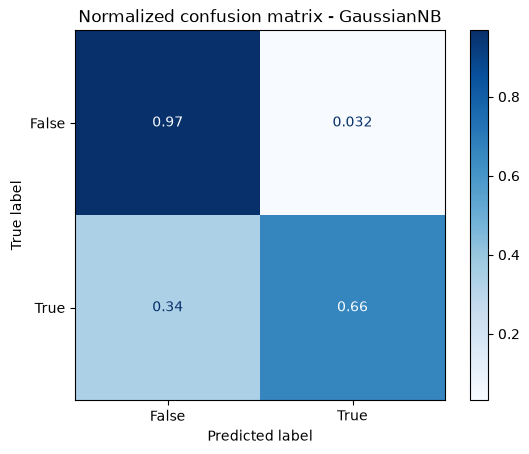

DecisionTreeClassifier


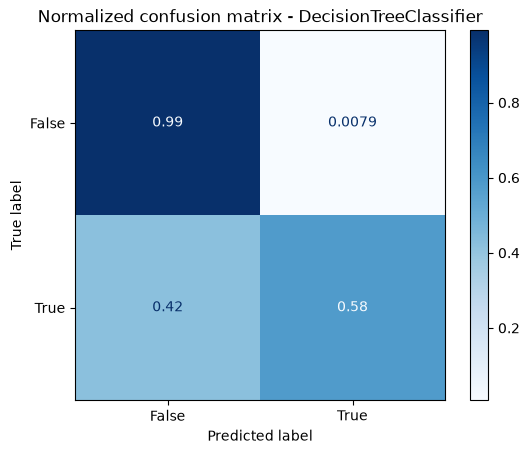

GradientBoostingClassifier


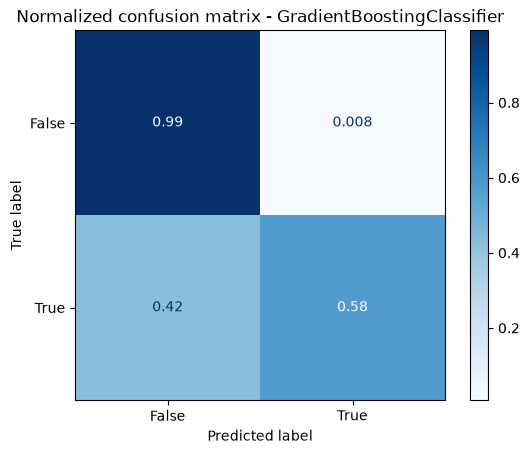

RandomForestClassifier


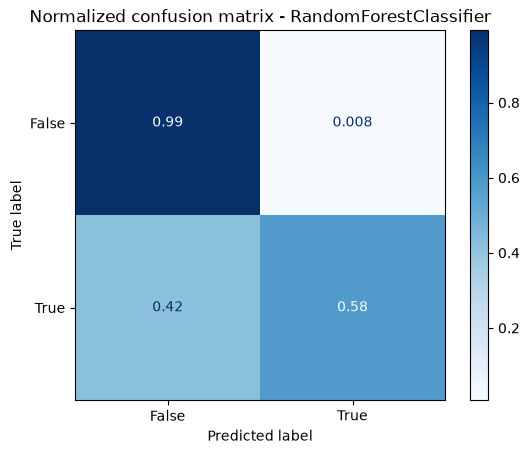

In [44]:
plotConfusionMatrix(nb_model,X_test,y_test)
plotConfusionMatrix(dtc_model,X_test,y_test)
plotConfusionMatrix(gbc_model,X_test,y_test)
plotConfusionMatrix(rf,X_test,y_test)


